In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from dmri.simulators import BallStickZeppelinNoise
from dmri.simulators.acquisition_scheme import acquisition_scheme
from flax import nnx

import matplotlib.pyplot as plt

plt.style.use("../dmri/utils/pyloric_black.mplstyle")

# Ignore font warnings from matplotlib
import warnings
warnings.filterwarnings("ignore")
# Ignore missing font warnings from seaborn
warnings.filterwarnings("ignore", module="matplotlib.font_manager")


sim_type = BallStickZeppelinNoise
ball_stick = sim_type.from_theta(np.random.randn(sim_type.theta_dim))

Duplicate key in file '../dmri/utils/pyloric_black.mplstyle', line 65 ('savefig.facecolor    : black       # Ensures black background when saving')


In [3]:
from omegaconf import OmegaConf
res_folder = "/home/macke/mgloeckler90/dmri/results/dmri_ball_sticks_zeppelins3"
config_path = res_folder + "/2025-03-12_13-30-31/0/.hydra/config.yaml"
cfg = OmegaConf.load(config_path)
print(cfg)

{'name': 'dmri_ball_sticks_zeppelins3', 'seed': 0, 'use_wandb': True, 'wandb': {'project': 'dmri_ball3sticks3zeppelins', 'entity': None}, 'simulator': {'sim_type': {'name': 'Ball3Stick3ZeppelinNoise'}, 'acquisition_scheme': {'name': 'hardi', 'params': {'num_acquisitions': 200}}, 'prior_mask_alpha': 1.0, 'prior_mask_beta': 1.0}, 'model': {'embedding_net': {'name': 'DMRIEmbeddingConfig', 'params': {'num_layers': 2, 'num_heads': 4, 'widening_factor': 4, 'attn_size': 16, 'dropout_rate': None, 'bvals_embed_dim': 12, 'signals_embed_dim': 12, 'bvec_repeats': 4, 'log_transform_signals': True}}, 'inference_net': {'name': 'DMRIThetaInferenceConfig', 'params': {'num_layers': 6, 'num_heads': 4, 'widening_factor': 4, 'attn_size': 16, 'context_dim': 64, 'dropout_rate': None}}, 'model_selection_net': {'name': 'DMRIModelSelectionAmortizedPriorConfig', 'params': {'num_layers': 4, 'num_heads': 4, 'widening_factor': 4, 'attn_size': 16, 'dropout_rate': None, 'context_dim': 64, 'mask_prior_dim': 1}}, 'init

In [4]:
from dmri.train.build_model import build_model
from dmri.train.build_simulator import build_simulator


sim_type, simulator = build_simulator(cfg)
model = build_model(cfg, sim_type)
model.eval()

graphdef, params, static, state = nnx.split(model, nnx.Param, nnx.Intermediate, ...)

In [5]:
# Learning rate scheduler and optimizer
import optax
optimizer_cfg = cfg.train.optimizer
optimizer_type = getattr(optax, optimizer_cfg.optimizer)
scheduler_type = getattr(optax, optimizer_cfg.scheduler)
use_ema = optimizer_cfg.get("ema", False)
use_adaptive_clip = optimizer_cfg.get("adaptive_gradient_clipping", False)
grad_transforms = []
if use_adaptive_clip:
    grad_clip = optax.adaptive_grad_clip(
        optimizer_cfg.get("gradient_clip_value", 10.0)
    )
    grad_transforms.append(grad_clip)
scheduler = scheduler_type(**optimizer_cfg.scheduler_params)
optimizer = optimizer_type(scheduler)
grad_transforms.append(optimizer)
if use_ema:
    grad_transforms.append(optax.ema(optimizer_cfg.get("ema_decay", 0.8)))

# Initialize optimizer
optimizer = optax.chain(*grad_transforms)

In [6]:
from dmri.train.checkpointing import CheckpointManager
checkpoint_dir = res_folder + "/checkpoints"
continue_training = True
checkpoint_manager = CheckpointManager(
        ckpt_dir=checkpoint_dir,
        max_to_keep=cfg.get("max_checkpoints", 3),
        keep_best=cfg.get("keep_best_checkpoint", True),
        recovery_threshold=cfg.get("recovery_threshold", float("inf")),
        continue_training=continue_training,
        use_async=cfg.get(
            "use_async_checkpointing", True
        ),  # Enable async checkpointing
    )

In [7]:
latest_step = checkpoint_manager.get_latest_step()
opt_state = optimizer.init(params)

In [8]:
checkpoint = checkpoint_manager.restore(
                step=latest_step, params=params, optimizer_state=opt_state,
            )

In [9]:
params = checkpoint["params"]

In [10]:
model = nnx.merge(graphdef, params, static, state)
model.eval()

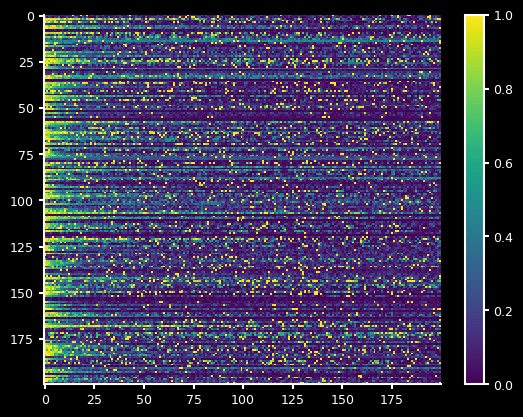

In [11]:
p_mask,masks, theta, x_o, acq = jax.vmap(simulator)(jax.random.split(jax.random.PRNGKey(0), num=200))

plt.imshow(x_o, aspect='auto', vmin=0, vmax=1)
plt.colorbar()

In [12]:
model.train()

In [28]:
import optax

scheduler = optax.cosine_onecycle_schedule(200*500, 1e-4)
optimizer = optax.chain(optax.adaptive_grad_clip(100.), optax.ema(0.9), optax.adamw(scheduler))

opt_state = optimizer.init(params)


In [23]:

def loss_fn(params, data, rng):
    nnx.update(model, params)
    p_mask, model_mask, thetas,  xs, bvals, bvecs = data

    return model.loss_fn(params, rng,model_mask=model_mask, theta=thetas, x=xs,bvals=bvals, bvecs=bvecs, mask_prior=p_mask).sum()


@jax.jit
def update(params, opt_state, data, rng):
    loss, grads = jax.value_and_grad(loss_fn)(params, data, rng)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state, loss

In [24]:
opt_state = optimizer.init(params)

In [25]:
batch_simulator = jax.jit(jax.vmap(simulator))

In [29]:
key = jax.random.PRNGKey(43)
for i in range(200):
    key, subkey1 = jax.random.split(key, 2)
    p_mask, masks, thetas, x_os, acq = batch_simulator(jax.random.split(subkey1, 2**16))
    l = 0
    for j in range(500):
        key, subkey2 = jax.random.split(key, 2)
        idx = jax.random.randint(subkey2, (512,), 0, 2**16)
        p_mask_batch, masks_batch, thetas_batch, x_os_batch, bvals_batch, bvecs_batch = p_mask[idx],masks[idx], thetas[idx], x_os[idx], acq.bvals[idx], acq.bvecs[idx]
        params, opt_state, loss = update(params, opt_state, (p_mask_batch,masks_batch, thetas_batch, x_os_batch, bvals_batch, bvecs_batch), subkey2)
        l += loss
    print(l/500)

7.847913
7.834902
7.800828
7.802783
7.808978
7.829732
7.817973
7.8187194
7.8493657
7.8248057
7.8516746
7.8464117
7.839553
7.8918934
7.815952
7.8402996
7.8236356
7.828623
7.8254814
7.8199067
7.8126006
7.827114
7.830558
7.825091
7.8371162
7.8425784
7.850731
7.84855
7.8546543
7.8458543
7.852195
7.857557
7.852527
7.861634
7.8706603
7.8557367
7.8760643
7.8522677
7.866324
7.862338
7.8641324
7.8569202
7.862801
7.871939
7.8606324
7.856293
7.856784
7.857837
7.8772206
7.853939
7.8541775
7.8512115
7.8692346
7.85232
7.858364
7.8624787
7.8547535
7.8543987
7.8670225
7.8644056
7.86286
7.868104
7.852196
7.873166
7.8645945
7.854797
7.866676
7.8793554
7.875078
7.8647704
7.8630834
7.868402
7.868611
7.879986
7.864723
7.8505435
7.8573446
7.863842
7.8590474
7.8626146
7.8459573
7.8432035
7.863852
7.8497553
7.8675203
7.8709297
7.8741155
7.8729906
7.8550005
7.8579526
7.8648205
7.8592863
7.864151
7.870015
7.8590183
7.8512063
7.848734
7.858776
7.869696
7.8588386
7.860072
7.863237
7.86044
7.8686256
7.8592653
7.84

In [ ]:
opt_state = optimizer.init(params)

key = jax.random.PRNGKey(43)
for i in range(30):
    key, subkey1 = jax.random.split(key, 2)
    p_mask, masks, thetas, x_os, acq = batch_simulator(jax.random.split(subkey1, 2**16))
    l = 0
    for j in range(500):
        key, subkey2 = jax.random.split(key, 2)
        idx = jax.random.randint(subkey2, (512,), 0, 2**16)
        p_mask_batch, masks_batch, thetas_batch, x_os_batch, bvals_batch, bvecs_batch = p_mask[idx],masks[idx], thetas[idx], x_os[idx], acq.bvals[idx], acq.bvecs[idx]
        params, opt_state, loss = update(params, opt_state, (p_mask_batch,masks_batch, thetas_batch, x_os_batch, bvals_batch, bvecs_batch), subkey2)
        l += loss
    print(l/500)

: 

In [43]:
nnx.update(model, params)

In [44]:
model(masks, theta, x_o, acq.bvals, acq.bvecs, p_mask)[0][0]

(0, 1, 2, 3, 4, 5, 6, 7, 8)


TypeError: Cannot concatenate arrays with different numbers of dimensions: got (65536, 200, 12), (200, 12), (65536, 200, 12).

In [14]:
nnx.display(model)

In [13]:
batch_simulator = jax.jit(jax.vmap(simulator))

In [14]:
p_mask, masks, thetas, x_os, acq = batch_simulator(jax.random.split(jax.random.key(0), 100))

In [15]:
#idx = 2
idx = 21
masks[idx]

Array([ True,  True,  True, False, False,  True,  True,  True, False],      dtype=bool)

In [16]:
mask = jax.vmap(model.sample_mask, in_axes=(0,None,None, None, None))(jax.random.split(jax.random.key(0), 256), acq.bvals[idx], acq.bvecs[idx], x_os[idx], jnp.array([0.5]))

(0, 1, 2, 3, 4, 5, 6, 7, 8)


In [17]:
mask_true= masks[idx]

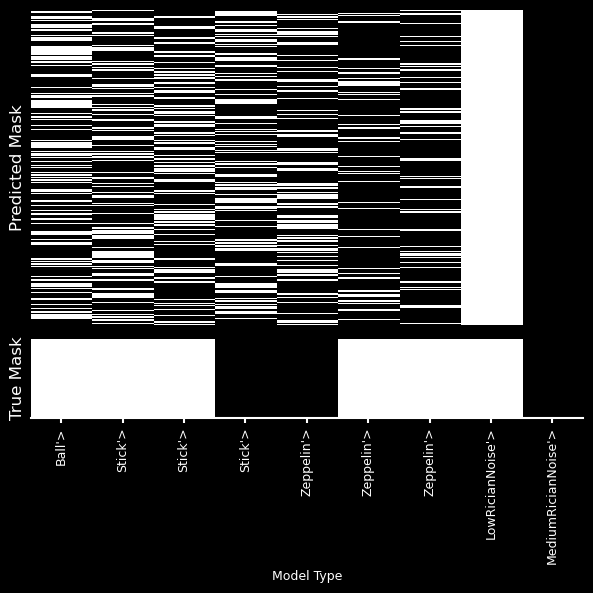

<Figure size 640x480 with 0 Axes>

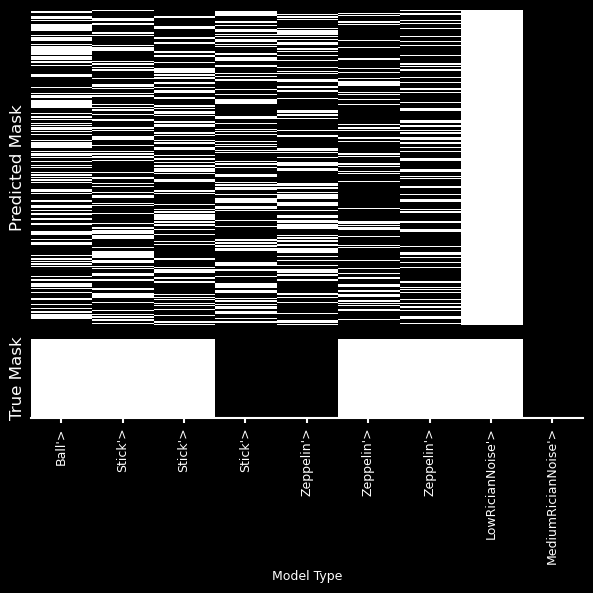

<Figure size 640x480 with 0 Axes>

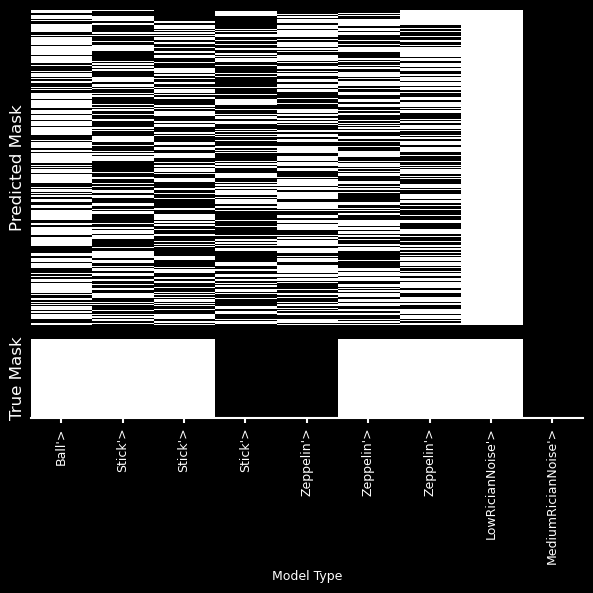

<Figure size 640x480 with 0 Axes>

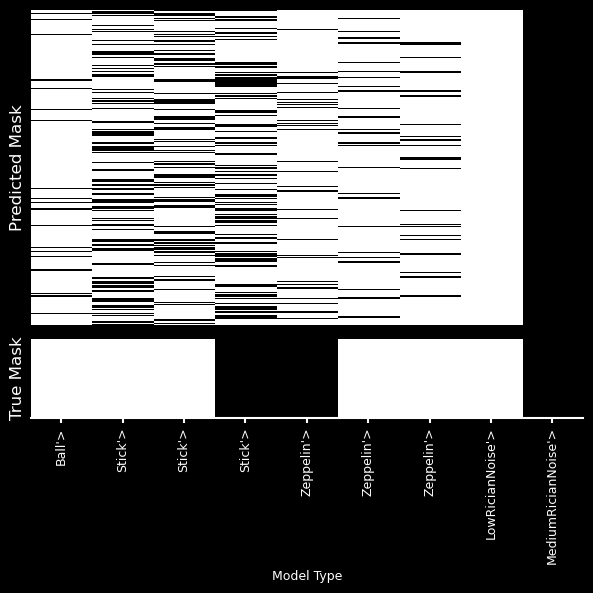

<Figure size 640x480 with 0 Axes>

In [18]:
import matplotlib.pyplot as plt

for t in [0.01, 0.1, 0.5, 0.9]:
    mask = jax.vmap(model.sample_mask, in_axes=(0,None,None, None, None))(jax.random.split(jax.random.key(0), 256), acq.bvals[idx], acq.bvecs[idx], x_os[idx], jnp.array([t]))
    plt.figure(figsize=(6, 6))

    # Create a grid with 90% height for the predicted mask and 10% height for the true mask
    grid = plt.GridSpec(2, 1, height_ratios=[8, 2])

    # Plot predicted mask on top subplot
    ax1 = plt.subplot(grid[0])
    ax1.imshow(mask, aspect='auto', cmap='gray', vmin=0, vmax=1)
    ax1.set_ylabel('Predicted Mask', fontsize=12)
    ax1.set_xticks([])  # Hide x-ticks
    ax1.set_yticks([])  # Hide y-ticks
    # Remove unnecessary spines
    ax1.spines['top'].set_visible(False)
    ax1.spines['left'].set_visible(False)
    ax1.spines['bottom'].set_visible(False)

    # Plot true mask on bottom subplot
    ax2 = plt.subplot(grid[1])
    ax2.imshow(mask_true[None], aspect='auto', cmap='gray', vmin=0, vmax=1)
    ax2.set_ylabel('True Mask', fontsize=12)
    ax2.set_xlabel('Model Type')

    # Set x-tick labels
    model_labels = [str(m).split(".")[-1] for m in sim_type.model_types] + [str(m).split(".")[-1] for m in sim_type.noise_types]
    ax2.set_xticks(range(len(sim_type.model_types) + len(sim_type.noise_types)))
    ax2.set_xticklabels(model_labels, rotation=90)

    # Remove y-axis ticks
    ax2.set_yticks([])
    # Remove unnecessary spines
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['left'].set_visible(False)

    plt.tight_layout()
    plt.show()

    plt.savefig(f"../figures/large_model/mask_posterior_t={t}_idx={idx}.svg")
    plt.savefig(f"../figures/large_model/mask_posterior_t={t}_idx={idx}.png")

In [19]:
from functools import partial

In [20]:
masks[idx]

Array([ True,  True,  True, False, False,  True,  True,  True, False],      dtype=bool)

In [21]:
thetas_post = jax.vmap(partial(model.sample_theta, num_steps=256, max_noise=20), in_axes=(0,None,None, None, None))(jax.random.split(jax.random.key(0), 4096), acq.bvals[idx], acq.bvecs[idx], x_os[idx],masks[idx])

(0, 1, 2, 3, 4, 5, 6, 7, 8)


In [52]:
def importance_resample(key, K=10):
    key, subkey = jax.random.split(key)
    key_propose = jax.random.split(subkey, K)
    samples, log_probs = jax.vmap(partial(model.sample_and_log_prob_theta, num_steps=32, max_noise=80), in_axes=(0,None,None, None, None))(key_propose, acq.bvals[idx], acq.bvecs[idx], x_os[idx],masks[idx])
    log_probs_posterior = jax.vmap(log_posterior)(samples)
    weights = log_probs_posterior - log_probs
    weights = jax.nn.softmax(weights)
    sample = jax.random.choice(subkey, samples, p=weights)
    return sample

In [53]:
thetas_post = jax.vmap(importance_resample)(jax.random.split(jax.random.key(0), 1024))

(0, 1, 2, 3, 4, 5, 6, 7, 8)


In [54]:
thetas_post.shape

(1024, 30)

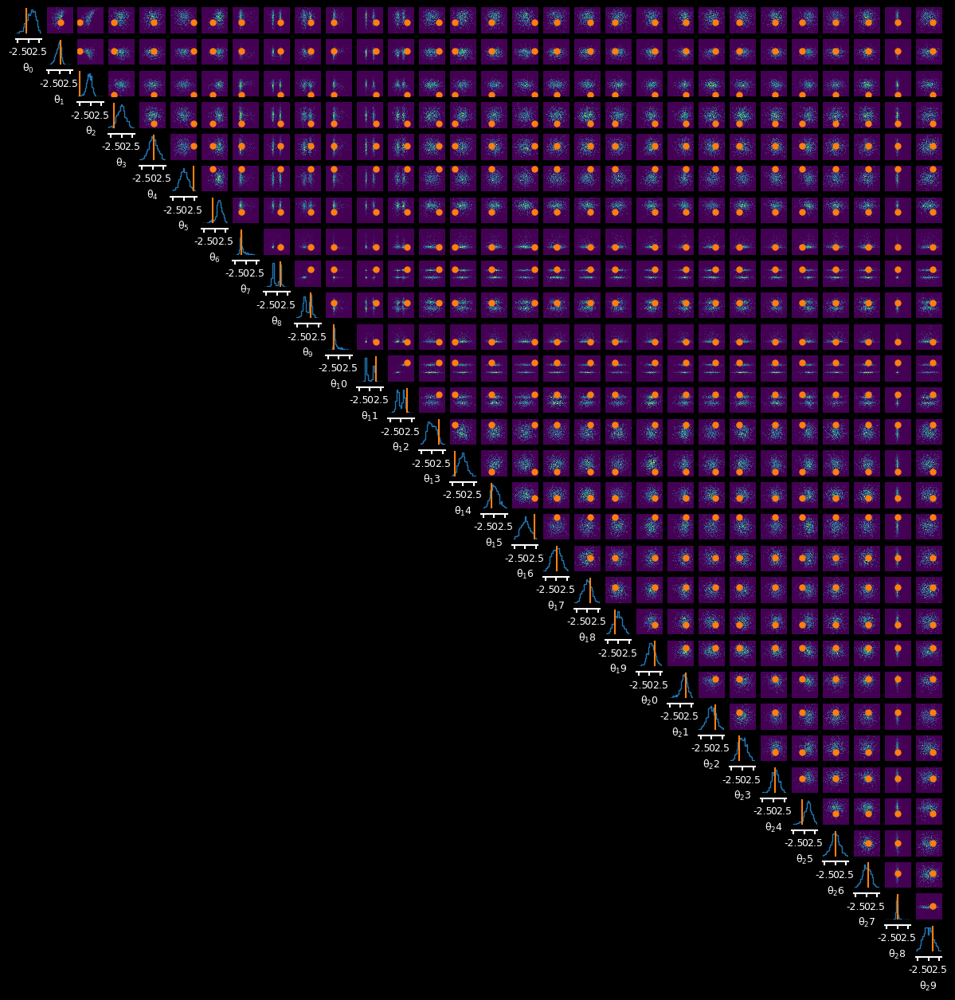

: 

In [ ]:
import sbi
from sbi.analysis.plot import pairplot

fig,axes = pairplot(thetas_post, points=[thetas[idx],], limits=[[-3,3]*100], labels=[f'$\\theta_{i}$' for i in range(100)], figsize=(15, 15))
fig.savefig(f"../figures/large_model/posterior_pairplot_idx{idx}.svg")
fig.savefig(f"../figures/large_model/posterior_pairplot_idx{idx}.png")

In [45]:
def posterior_pred(theta,rng):
    return sim_type.from_theta(theta, model_mask=masks[idx]).signal(acquisition_scheme(acq.bvals[idx], acq.bvecs[idx]), rng=rng)

def loglikelihood(theta):
    simulator = sim_type.from_theta(theta, model_mask=masks[idx])
    ll = simulator.log_likelihood(acquisition_scheme(acq.bvals[idx], acq.bvecs[idx]), x_os[idx])
    return ll

posterior_preds = jax.vmap(posterior_pred)(thetas_post, jax.random.split(jax.random.key(0), 1024))

In [46]:
ll = loglikelihood(thetas[idx])

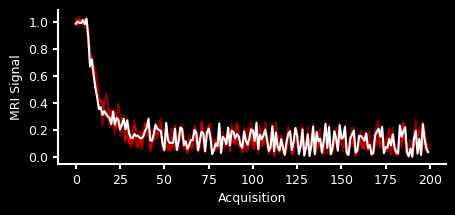

In [47]:
bvals = acq.bvals[idx]
bvecs = acq.bvecs[idx]
sort_bvals = jnp.argsort(bvals)
bvals = bvals[sort_bvals]
posterior_preds_sorted = posterior_preds[:,sort_bvals]
x_o = x_os[idx][sort_bvals]


fig = plt.figure(figsize=(5, 2))

_ = plt.plot(posterior_preds_sorted[:5].T, label="posterior pred", color="red", alpha=0.5)
_ = plt.plot(posterior_preds_sorted.mean(0).T, label="posterior pred mean", color="darkred", linewidth=2)
_ = plt.plot(x_o, label="data", color="white")
plt.xlabel("Acquisition")
plt.ylabel("MRI Signal")

fig.savefig(f"../figures/large_model/posterior_pred_idx={idx}.svg")
fig.savefig(f"../figures/large_model/posterior_pred_idx={idx}.png")

In [28]:
def log_posterior(theta):
    return loglikelihood(theta) + jax.scipy.stats.norm.logpdf(theta, 0, 1).sum()

def log_q(theta):
    return model.log_prob_theta(theta, acq.bvals[idx], acq.bvecs[idx], x_os[idx], masks[idx], num_steps=128, max_noise=80)

@jax.jit
def effectve_sample_size(thetas):
    logp = jax.vmap(log_posterior)(thetas)
    logq = jax.vmap(log_q)(thetas)
    log_w = logp - logq
    # Self normalized importance weights
    w = jax.nn.softmax(log_w)
    return 1/jnp.sum(w**2)


In [29]:
effectve_sample_size(thetas_post)

(0, 1, 2, 3, 4, 5, 6, 7, 8)


Array(1.168, dtype=float32)

In [145]:
from dipy.data import get_fnames
from dipy.io.gradients import read_bvals_bvecs
from dipy.io.image import load_nifti
hardi_fname, hardi_bval_fname, hardi_bvec_fname = get_fnames(name="stanford_hardi")

data, affine = load_nifti(hardi_fname)

bvals, bvecs = read_bvals_bvecs(hardi_bval_fname, hardi_bvec_fname)


In [146]:
from dipy.segment.mask import median_otsu

datamask, mask_brain = median_otsu(
    data, vol_idx=range(10, 50), median_radius=3, numpass=1, autocrop=True, dilate=2
)
b0_mask = bvals == 0

In [147]:
# Data sub
S0 = np.mean(datamask[..., b0_mask], -1)
data_norm = datamask / S0[..., None]
data_norm = np.nan_to_num(data_norm)
x_o = data_norm[:, :, 28:29].squeeze()
S_o = S0[:, :, 28:29].squeeze()


Text(0.5, 1.0, 'HCP coronal slice B0 with ROI')

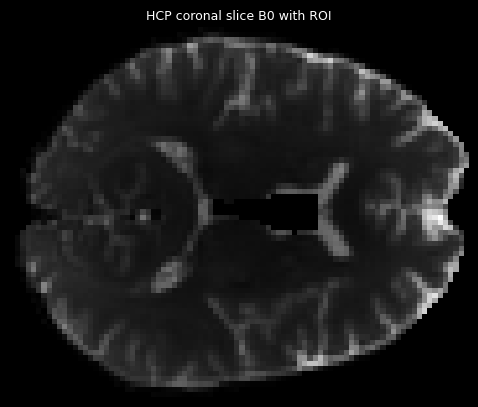

In [148]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
%matplotlib inline

fig, ax = plt.subplots(1)
ax.imshow(S_o, cmap='gray', origin='lower')
ax.set_axis_off()
ax.set_title('HCP coronal slice B0 with ROI')

In [149]:
acq = acquisition_scheme(jnp.array(bvals), jnp.array(bvecs))
x_o_flat = x_o.reshape(-1, x_o.shape[-1])

In [150]:
sample_mask_per_x= jax.jit(jax.vmap(lambda k, x: model.sample_mask(k, acq.bvals, acq.bvecs, x, mask_prior=jnp.array([0.5])), in_axes=(0,0)))

mask = sample_mask_per_x(jax.random.split(jax.random.key(0), x_o_flat.shape[0]), x_o_flat).astype(jnp.float32)
for i in range(1,201):
    mask += sample_mask_per_x(jax.random.split(jax.random.key(i), x_o_flat.shape[0]), x_o_flat).astype(jnp.float32)
p_models = mask / 200

p_models = p_models.reshape(x_o.shape[:-1] + (p_models.shape[-1],))

(0, 1, 2, 3, 4)


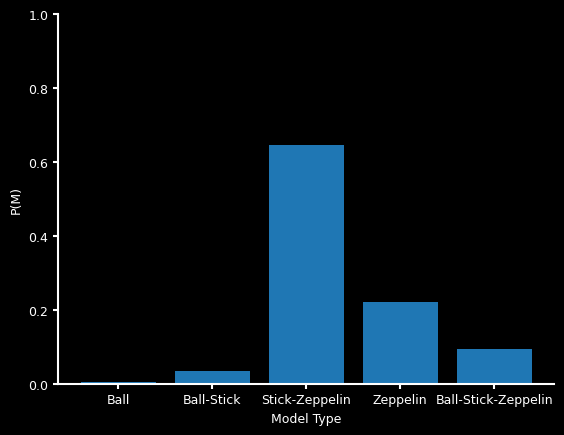

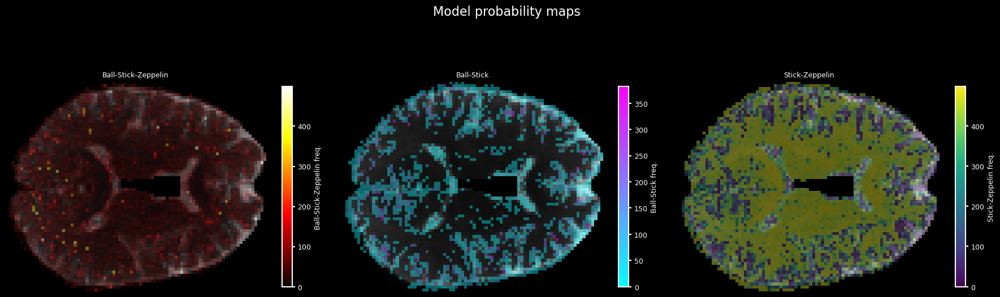

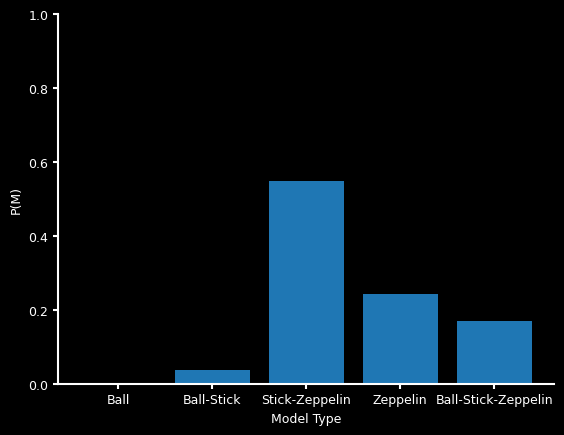

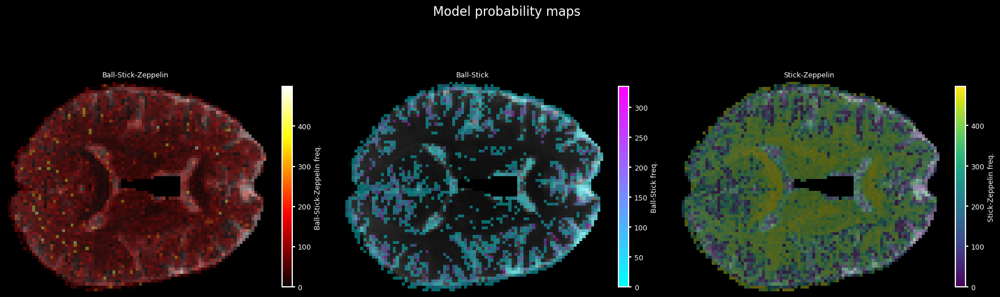

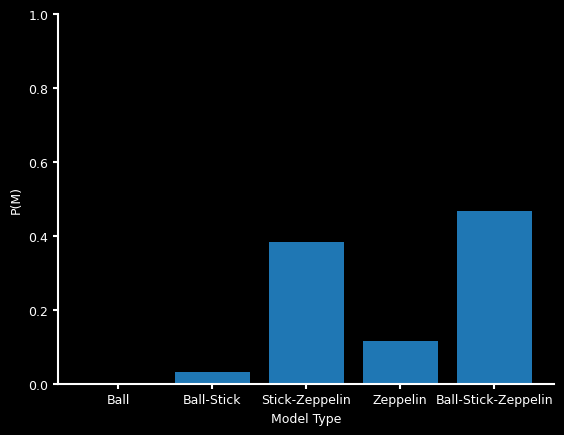

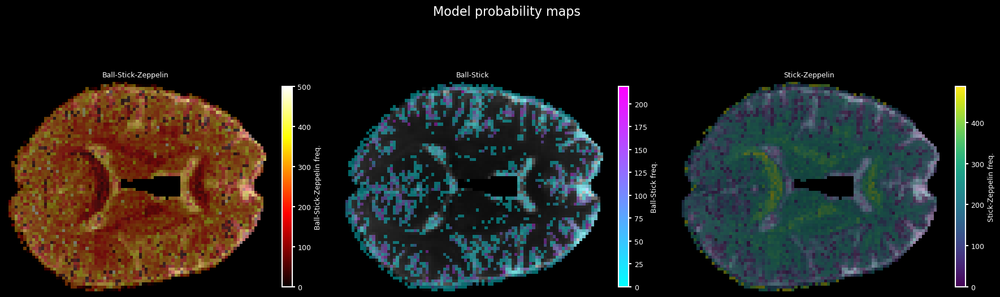

In [198]:
for p in [0.1, 0.2, 0.5]:
    sample_mask_per_x= jax.jit(jax.vmap(lambda k, x: model.sample_mask(k, acq.bvals, acq.bvecs, x, mask_prior=jnp.array([p])), in_axes=(0,0)))
    num_balls, num_ball_stick, num_stick_zeppelin, num_zeppelin, num_ball_stick_zeppelin = 0, 0, 0, 0, 0
    for i in range(1,501):
        mask = sample_mask_per_x(jax.random.split(jax.random.key(i), x_o_flat.shape[0]), x_o_flat).astype(jnp.float32)
        balls = (mask[...,:3] == jnp.array([True, False, False])).all(-1)
        num_balls += balls
        ball_stick = (mask[...,:3] == jnp.array([True, True, False])).all(-1)
        num_ball_stick += ball_stick
        stick_zeppelin = (mask[...,:3] == jnp.array([False, True, True])).all(-1)
        num_stick_zeppelin += stick_zeppelin
        zeppelin = (mask[...,:3] == jnp.array([False, False, True])).all(-1)
        num_zeppelin += zeppelin
        ball_stick_zeppelin = (mask[...,:3] == jnp.array([True, True, True])).all(-1)
        num_ball_stick_zeppelin += ball_stick_zeppelin

    total = sum([num_balls.sum(), num_ball_stick.sum(), num_stick_zeppelin.sum(), num_zeppelin.sum(), num_ball_stick_zeppelin.sum()])
    plt.bar(["Ball", "Ball-Stick", "Stick-Zeppelin", "Zeppelin", "Ball-Stick-Zeppelin"], [num_balls.sum()/total, num_ball_stick.sum()/total, num_stick_zeppelin.sum()/total, num_zeppelin.sum()/total, num_ball_stick_zeppelin.sum()/total])
    plt.ylabel("P(M)")
    plt.xlabel("Model Type")
    plt.ylim(0, 1)
    plt.savefig(f"../figures/model_posterior_total_p{p}.svg")
    plt.savefig(f"../figures/model_posterior_total_p{p}.png")
    plt.show()


    mask_brain_sub = mask_brain[:, :, 28]

    # Create a 1x3 subplot layout
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Model probability maps', fontsize=16)

    # Reshape the model probability arrays to match the 2D spatial dimensions of x_o
    num_bsz_reshaped = num_ball_stick_zeppelin.reshape(x_o.shape[0], x_o.shape[1])
    num_bs_reshaped = num_ball_stick.reshape(x_o.shape[0], x_o.shape[1])
    num_sz_reshaped = num_stick_zeppelin.reshape(x_o.shape[0], x_o.shape[1])

    # Apply the brain mask to only show values within the brain
    masked_bsz_overlay = num_bsz_reshaped * mask_brain_sub
    masked_bs_overlay = num_bs_reshaped * mask_brain_sub
    masked_sz_overlay = num_sz_reshaped * mask_brain_sub

    # Plot Ball-Stick-Zeppelin overlay in the first subplot
    im0 = axes[0].imshow(S_o, cmap='gray', origin='lower')
    bsz_im = axes[0].imshow(masked_bsz_overlay, cmap='hot', origin='lower',
                    alpha=0.4 * (masked_bsz_overlay > 0))
    bsz_cbar = fig.colorbar(bsz_im, ax=axes[0], shrink=0.7)
    bsz_cbar.set_label('Ball-Stick-Zeppelin freq.')
    axes[0].set_title('Ball-Stick-Zeppelin')
    axes[0].set_axis_off()

    # Plot Ball-Stick overlay in the second subplot
    im1 = axes[1].imshow(S_o, cmap='gray', origin='lower')
    bs_im = axes[1].imshow(masked_bs_overlay, cmap='cool', origin='lower',
                alpha=0.4 * (masked_bs_overlay > 0))
    bs_cbar = fig.colorbar(bs_im, ax=axes[1], shrink=0.7)
    bs_cbar.set_label('Ball-Stick freq.')
    axes[1].set_title('Ball-Stick')
    axes[1].set_axis_off()

    # Plot Stick-Zeppelin overlay in the third subplot
    im2 = axes[2].imshow(S_o, cmap='gray', origin='lower')
    sz_im = axes[2].imshow(masked_sz_overlay, cmap='viridis', origin='lower',
                alpha=0.4 * (masked_sz_overlay > 0))
    sz_cbar = fig.colorbar(sz_im, ax=axes[2], shrink=0.7)
    sz_cbar.set_label('Stick-Zeppelin freq.')
    axes[2].set_title('Stick-Zeppelin')
    axes[2].set_axis_off()

    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to make room for suptitle

    # Save figure
    plt.savefig(f"../figures/model_probability_maps_p{p}.svg")
    plt.savefig(f"../figures/model_probability_maps_p{p}.png")
    plt.show()

In [218]:
model_mask = jnp.array([True, True, False, True, False], dtype=jnp.bool)
sample_theta_per_x = jax.jit(jax.vmap(lambda k, x: model.sample_theta(k, acq.bvals, acq.bvecs, x, model_mask, num_steps=128, max_noise=80), in_axes=(0,0)))

thetas = []
for i in range(20):
    thetas.append(sample_theta_per_x(jax.random.split(jax.random.key(i), x_o_flat.shape[0]), x_o_flat))


(0, 1, 2, 3, 4)


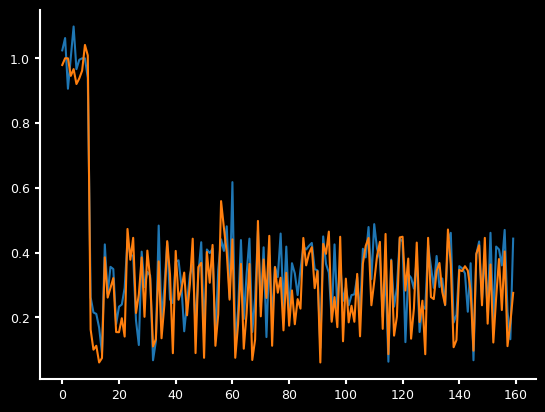

In [205]:

def sim_theta(key, theta):
    simulator = sim_type.from_theta(theta, model_mask=model_mask)
    x_pred = simulator.signal(acq, rng=key)
    return x_pred

x_preds = jax.vmap(sim_theta)(jax.random.split(jax.random.key(0), thetas[0].shape[0]), thetas[3])
i = 4000
plt.plot(x_o_flat[i], label="data")
plt.plot(x_preds[i], label="pred")

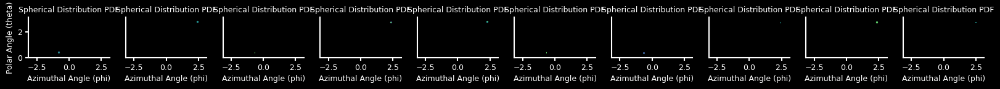

In [206]:
fig, axes = plt.subplots(1, 10, figsize=(20, 4))

for j in range(10):
    fod = sim_type.from_theta(thetas[j][i], model_mask=model_mask).to_fod()
    fod.viz(plot_type="polar",n_samples=5_00, ax=axes[j])
    if j > 0:
        axes[j].set_ylabel("")
        axes[j].set_yticks([])

In [208]:
def to_params_dict(theta):
    simulator = sim_type.from_theta(theta, model_mask=model_mask)
    fractions = simulator.model_fractions
    components = simulator.model_compartments
    noise = simulator.noise_compartments

    com_params = [c.params for c in components]
    noise_params = [n.params for n in noise]
    return {"fractions": fractions, "components": com_params, "noise": noise_params}

In [209]:
from dmri.utils.dmriutils import unitsphere_to_cartesian


all_params = jax.vmap(to_params_dict)(thetas[0])
frac = all_params["fractions"]
lam_iso = all_params["components"][0]["lam"]
lam_par = all_params["components"][1]["lam_par"]
mu = all_params["components"][1]["mu"]
direction = jax.vmap(unitsphere_to_cartesian)(mu)


In [227]:
import imageio
import os
from IPython.display import Image, display
import tempfile

# Create temporary directory for frames
temp_dir = tempfile.mkdtemp()

# Create frames for each theta in thetas
frames = []
for i, theta_sample in enumerate(thetas):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor='black')

    all_params = jax.vmap(to_params_dict)(theta_sample)
    frac = all_params["fractions"]
    lam_iso = all_params["components"][0]["lam"]
    lam_par = all_params["components"][1]["lam_par"]
    mu = all_params["components"][1]["mu"]
    direction = jax.vmap(unitsphere_to_cartesian)(mu)

    # First model fraction (Ball fraction)
    im0 = axes[0].imshow(mask_brain_sub * frac[:, 0].reshape(x_o.shape[:-1]), vmin=0, vmax=1, cmap='inferno')
    axes[0].set_title('Ball Fraction', color='white')
    axes[0].set_axis_off()

    # Second model fraction (Stick fraction)
    im1 = axes[1].imshow(mask_brain_sub * frac[:, 1].reshape(x_o.shape[:-1]), vmin=0, vmax=1, cmap='inferno')
    axes[1].set_title('Stick Fraction', color='white')
    axes[1].set_axis_off()
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    fig.suptitle(f'Model Compartment Fractions - Sample {i+1}', fontsize=16, color='white')

    # Save frame
    frame_path = os.path.join(temp_dir, f'frame_{i:02d}.png')
    plt.savefig(frame_path)
    plt.close(fig)
    frames.append(frame_path)

# Create GIF from frames
gif_path = '../figures/model_fractions_animation.gif'
with imageio.get_writer(gif_path, mode='I', duration=10) as writer:
    for frame_path in frames:
        image = imageio.imread(frame_path)
        writer.append_data(image)

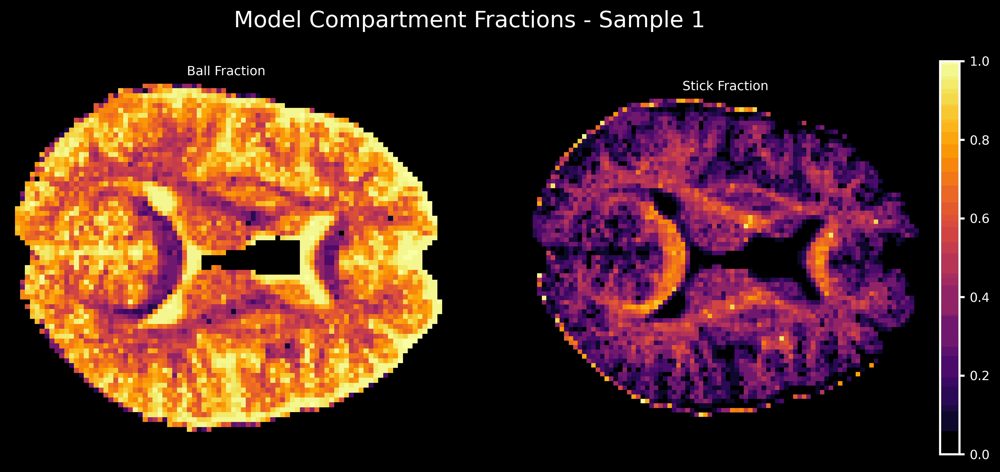

In [230]:

# Display the GIF
display(Image(gif_path))


In [231]:


all_params = jax.vmap(to_params_dict)(thetas[0])
frac = all_params["fractions"]
lam_iso = all_params["components"][0]["lam"]
lam_par = all_params["components"][1]["lam_par"]
mu = all_params["components"][1]["mu"]
direction = jax.vmap(unitsphere_to_cartesian)(mu)

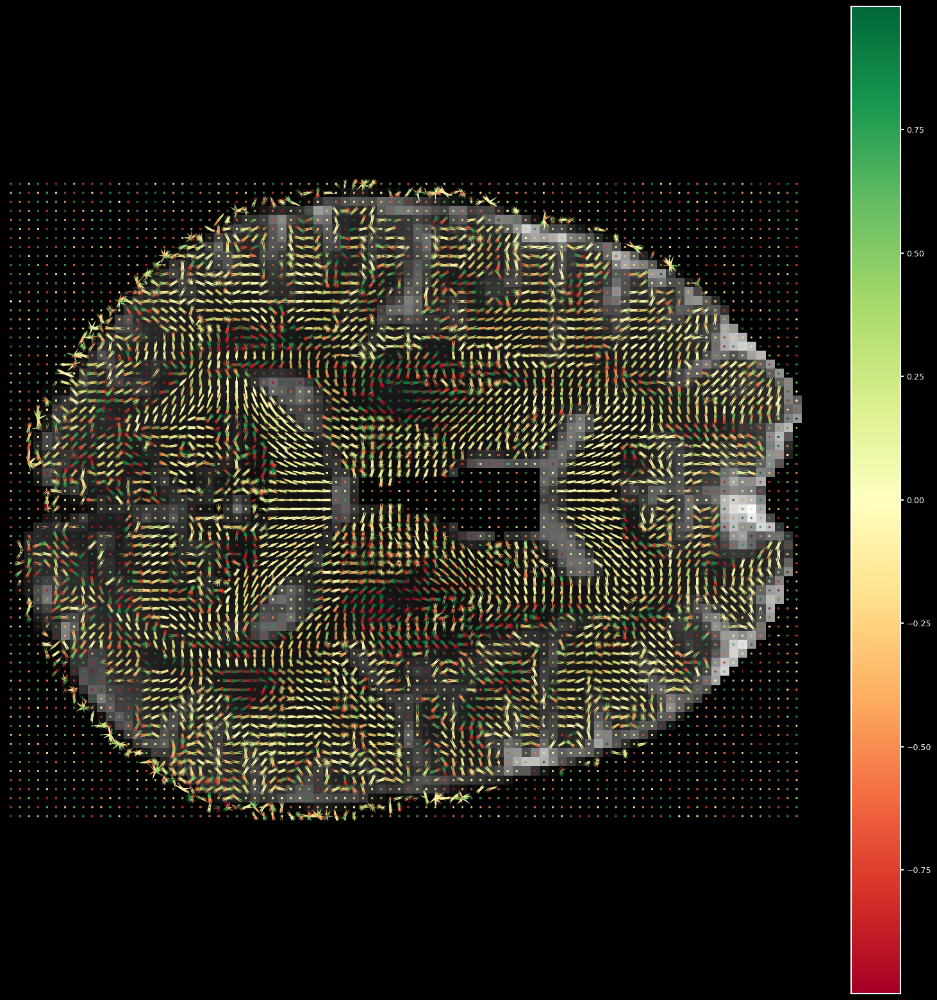

In [237]:
fig, ax = plt.subplots(1, figsize=(20,20))
shape_img = x_o.shape[:-1]
ax.imshow(mask_brain_sub*S_o.reshape(shape_img), cmap='gray', origin='lower')


for i in range(20):
    # For example, use the first sample in thetas
    all_params = jax.vmap(to_params_dict)(thetas[i])
    frac    = all_params["fractions"]
    lam_par = all_params["components"][1]["lam_par"]
    mu      = all_params["components"][1]["mu"]

    # Convert unit sphere directions to 3D cartesian coordinates.
    direction = jax.vmap(unitsphere_to_cartesian)(mu)
    # Compute 2D projection using the first two components.
    direction_2d = 2*direction[:, :2] * frac[:, 1][:, None] * (lam_par[:, None] > 0)

    # Use the third component (z) as the color code.
    colors = direction[:, 2]

    # Create a grid for quiver
    X, Y = np.meshgrid(np.arange(shape_img[1]), np.arange(shape_img[0]))
    q = ax.quiver(X, Y, direction_2d[:, 0].reshape(shape_img)*mask_brain_sub,
                  direction_2d[:, 1].reshape(shape_img)*mask_brain_sub,
                  colors.reshape(shape_img), cmap="RdYlGn", scale=150, headwidth=0, headlength=0)
plt.colorbar(q)
ax.set_axis_off()
plt.show()

fig.savefig(f"../figures/ball_and_stick_model_directions.svg")
fig.savefig(f"../figures/ball_and_stick_model_directions.png")

In [238]:
# Ball and Zeppelins

model_mask = jnp.array([True, True, True, True, False], dtype=jnp.bool)
sample_theta_per_x = jax.jit(jax.vmap(lambda k, x: model.sample_theta(k, acq.bvals, acq.bvecs, x, model_mask, num_steps=128, max_noise=80), in_axes=(0,0)))

thetas = []
for i in range(10):
    thetas.append(sample_theta_per_x(jax.random.split(jax.random.key(i), x_o_flat.shape[0]), x_o_flat))

def sim_theta(key, theta):
    simulator = sim_type.from_theta(theta, model_mask=model_mask)
    x_pred = simulator.signal(acq, rng=key)
    return x_pred


(0, 1, 2, 3, 4)


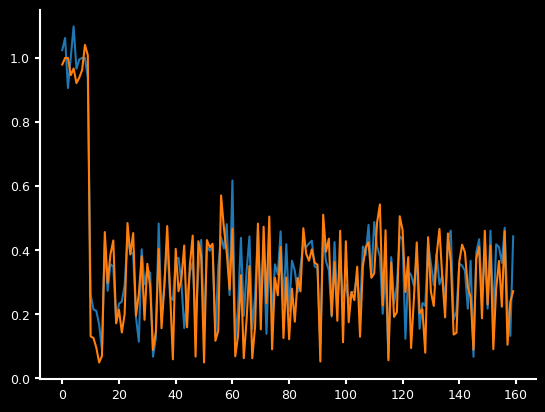

In [239]:
x_preds = jax.vmap(sim_theta)(jax.random.split(jax.random.key(0), thetas[0].shape[0]), thetas[3])

i = 4000
plt.plot(x_o_flat[i], label="data")
plt.plot(x_preds[i], label="pred")

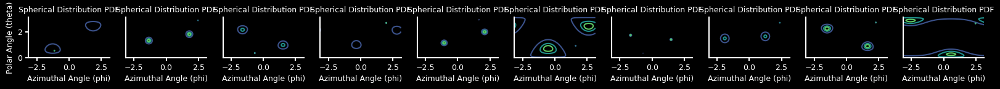

In [240]:
fig, axes = plt.subplots(1, 10, figsize=(20, 2))

for j in range(10):
    fod = sim_type.from_theta(thetas[j][i], model_mask=model_mask).to_fod()
    fod.viz(plot_type="polar",n_samples=5_00, ax=axes[j])
    if j > 0:
        axes[j].set_ylabel("")
        axes[j].set_yticks([])

In [246]:
def to_fod_sample(theta, rng):
    simulator = sim_type.from_theta(theta, model_mask=model_mask)
    fod = simulator.to_fod()
    return fod.fractions, fod.sample(rng, shape=(50,))

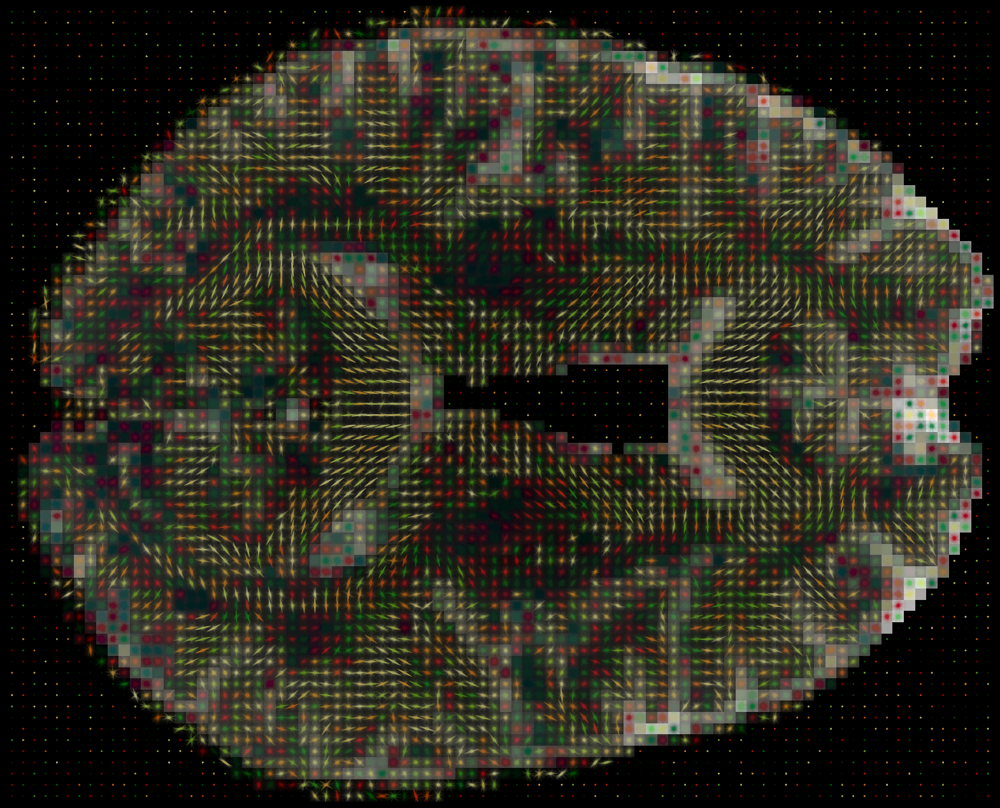

<Figure size 640x480 with 0 Axes>

In [250]:
fig, ax = plt.subplots(1, figsize=(20,20))
shape_img = x_o.shape[:-1]
ax.imshow(mask_brain_sub*S_o.reshape(shape_img), cmap='gray', origin='lower')


for i in range(10):
    theta = thetas[i]
    fractions, directions = jax.vmap(to_fod_sample)(theta, jax.random.split(jax.random.key(i), theta.shape[0]))
    for i in range(50):

        # Use the third component (z) as the color code.
        direction_2d = directions[:, i,:2]
        colors = direction[:, 2]

        # Create a grid for quiver
        X, Y = np.meshgrid(np.arange(shape_img[1]), np.arange(shape_img[0]))
        q = ax.quiver(X, Y, direction_2d[:, 0].reshape(shape_img)*mask_brain_sub,
                    direction_2d[:, 1].reshape(shape_img)*mask_brain_sub,
                    colors.reshape(shape_img), cmap="RdYlGn", scale=100, headwidth=0, headlength=0, alpha=0.01)
#plt.colorbar(q)
ax.set_axis_off()
plt.show()

plt.savefig(f"../figures/ball_and_zeppelin_model_directions_fod.svg")
plt.savefig(f"../figures/ball_and_zeppelin_model_directions_fod.png")

In [262]:
from dipy.core.gradients import gradient_table
from dipy.data import default_sphere, get_fnames, small_sphere
from dipy.direction import ProbabilisticDirectionGetter, peaks_from_model
from dipy.io.gradients import read_bvals_bvecs
from dipy.io.image import load_nifti, load_nifti_data
from dipy.io.stateful_tractogram import Space, StatefulTractogram
from dipy.io.streamline import save_trk
from dipy.reconst.csdeconv import ConstrainedSphericalDeconvModel, auto_response_ssst
from dipy.reconst.shm import CsaOdfModel
from dipy.tracking import utils
from dipy.tracking.local_tracking import LocalTracking
from dipy.tracking.stopping_criterion import ThresholdStoppingCriterion
from dipy.tracking.streamline import Streamlines
from dipy.viz import actor, colormap, has_fury, window

# Enables/disables interactive visualization
interactive = False

hardi_fname, hardi_bval_fname, hardi_bvec_fname = get_fnames(name="stanford_hardi")
label_fname = get_fnames(name="stanford_labels")

data, affine, hardi_img = load_nifti(hardi_fname, return_img=True)
labels = load_nifti_data(label_fname)
bvals, bvecs = read_bvals_bvecs(hardi_bval_fname, hardi_bvec_fname)
gtab = gradient_table(bvals, bvecs=bvecs)

seed_mask = labels == 2
white_matter = (labels == 1) | (labels == 2)
seeds = utils.seeds_from_mask(seed_mask, affine, density=1)

response, ratio = auto_response_ssst(gtab, data, roi_radii=10, fa_thr=0.7)
csd_model = ConstrainedSphericalDeconvModel(gtab, response, sh_order_max=6)
csd_fit = csd_model.fit(data, mask=white_matter)

In [3]:
csa_model = CsaOdfModel(gtab, sh_order_max=6)
gfa = csa_model.fit(data, mask=white_matter).gfa
stopping_criterion = ThresholdStoppingCriterion(gfa, 0.25)

NameError: name 'CsaOdfModel' is not defined

In [3]:


fod = csd_fit.odf(small_sphere)
pmf = fod.clip(min=0)
prob_dg = ProbabilisticDirectionGetter.from_pmf(
    pmf, max_angle=30.0, sphere=small_sphere
)
streamline_generator = LocalTracking(
    prob_dg, stopping_criterion, seeds, affine, step_size=0.5
)
streamlines = Streamlines(streamline_generator)
sft = StatefulTractogram(streamlines, hardi_img, Space.RASMM)
save_trk(sft, "tractogram_probabilistic_dg_pmf.trk")


scene = window.Scene()
scene.add(actor.line(streamlines, colors=colormap.line_colors(streamlines)))
window.record(
    scene=scene, out_path="tractogram_probabilistic_dg_pmf.png", size=(800, 800)
)

In [4]:
img = plt.imread("tractogram_probabilistic_dg_pmf.png")
plt.imshow(img)

NameError: name 'plt' is not defined

In [19]:
from dipy.data import default_sphere, get_fnames, small_sphere
x_o_full = np.nan_to_num(data)

In [20]:
x_o_select = x_o_full[white_matter]
x_o_select_b0 = x_o_select[..., bvals == 0]
x_o_select = x_o_select / x_o_select_b0.mean(-1)[..., None]

In [21]:
x_o_select_flat = x_o_select.reshape(-1, x_o_full.shape[-1])

In [22]:
acq = acquisition_scheme(jnp.array(bvals), jnp.array(bvecs))

In [78]:
model_mask = jnp.array([True, True, True, False, True], dtype=jnp.bool)
def sample_pmf(key, x):
    sample_fn = lambda k: model.sample_theta(k, acq.bvals, acq.bvecs, x, model_mask, num_steps=16, max_noise=20)
    pmf = 0

    def scan_fn(carry, key):
        thetas = jax.vmap(sample_fn)(jax.random.split(key,5))

        def to_pmf(theta):
            simulator = sim_type.from_theta(theta, model_mask=model_mask)
            return simulator.to_fod().to_pmf(small_sphere)

        pmf = 0
        for theta in thetas:
            pmf += to_pmf(theta)

        pmf_contrib = pmf / 5
        return carry + pmf_contrib, None

    # Use the first theta to determine the shape of the accumulator:
    init_sim = sim_type.from_theta(jnp.zeros(sim_type.theta_dim), model_mask=model_mask)
    init_pmf = init_sim.to_fod().to_pmf(small_sphere) * 0  # zeros of the same shape

    carry, _ = jax.lax.scan(scan_fn, init_pmf, jax.random.split(key, 10))
    pmf = carry

    return pmf / 10

batch_sample_pmf = jax.jit(jax.vmap(sample_pmf, in_axes=(0,0)))

In [79]:
pms = []
# Laptop has just 4GB of VRAM, so we need to split the computation
num_iters = x_o_select_flat.shape[0] // 3000 + 1

for i in range(num_iters):
    with jax.default_device(jax.devices("gpu")[0]):
        x_o_batch = x_o_select_flat[i*3000:(i+1)*3000]
        keys = jax.random.split(jax.random.key(i), x_o_batch.shape[0])
        pmf1 = batch_sample_pmf(keys,x_o_batch)
    pms.append(jax.device_put(pmf1, jax.devices("cpu")[0]))
    print(i)

(0, 1, 2, 3, 4)
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
(0, 1, 2, 3, 4)
19


In [80]:
pmf = jnp.concatenate(pms, axis=0)
pmf = pmf[:x_o_select_flat.shape[0]]
#pmf = pmf.reshape(x_o_select.shape[0], x_o_select.shape[1], x_o_select.shape[2], pmf.shape[-1])

In [81]:
x_o_select.shape

(58788, 160)

In [82]:
pmf = np.array(pmf)
pmf = np.nan_to_num(pmf, nan=1e-6)
pmf = np.clip(pmf, 0, 1)
pmf = pmf / pmf.sum(-1, keepdims=True)

In [83]:
pmf_full = np.zeros(data.shape[:-1] + (181,))
pmf_full[white_matter] = pmf

In [84]:
# np.save("pmf_full.npy", pmf_full)

In [10]:
import numpy as np
import matplotlib.pyplot as plt
pmf_full = np.load("pmf_full.npy")

(0.0, 0.1)

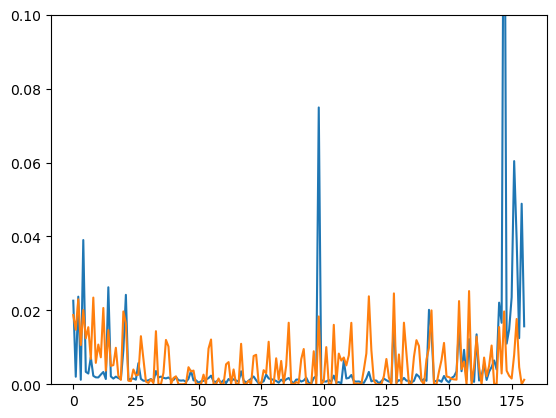

In [11]:
idx = 14
_ = plt.plot(pmf_full[white_matter][idx])
_ = plt.plot(pmf_dipy[white_matter][idx]/pmf_dipy[white_matter][idx].sum())
plt.ylim(0, 0.1)


In [12]:
data, affine, hardi_img = load_nifti(hardi_fname, return_img=True)
labels = load_nifti_data(label_fname)
bvals, bvecs = read_bvals_bvecs(hardi_bval_fname, hardi_bvec_fname)
gtab = gradient_table(bvals, bvecs=bvecs)

seed_mask = labels == 2
white_matter = (labels == 1) | (labels == 2)
seeds = utils.seeds_from_mask(seed_mask, affine, density=1)

response, ratio = auto_response_ssst(gtab, data, roi_radii=10, fa_thr=0.7)
csd_model = ConstrainedSphericalDeconvModel(gtab, response, sh_order_max=6)
csd_fit = csd_model.fit(data, mask=white_matter)

fod = csd_fit.odf(small_sphere)
pmf_dipy = fod.clip(min=0)

In [13]:
from dipy.tracking.stopping_criterion import CmcStoppingCriterion
hardi_fname, hardi_bval_fname, hardi_bvec_fname = get_fnames(name="stanford_hardi")
label_fname = get_fnames(name="stanford_labels")
f_pve_csf, f_pve_gm, f_pve_wm = get_fnames(name="stanford_pve_maps")

data, affine, hardi_img = load_nifti(hardi_fname, return_img=True)
labels = load_nifti_data(label_fname)
bvals, bvecs = read_bvals_bvecs(hardi_bval_fname, hardi_bvec_fname)
gtab = gradient_table(bvals, bvecs=bvecs)


pve_csf_data = load_nifti_data(f_pve_csf)
pve_gm_data = load_nifti_data(f_pve_gm)
pve_wm_data, _, voxel_size = load_nifti(f_pve_wm, return_voxsize=True)

voxel_size = np.average(voxel_size[1:4])
step_size = 0.2

cmc_criterion = CmcStoppingCriterion.from_pve(
    pve_wm_data,
    pve_gm_data,
    pve_csf_data,
    step_size=step_size,
    average_voxel_size=voxel_size,
)

In [14]:
# data, affine, hardi_img = load_nifti(hardi_fname, return_img=True)
# labels = load_nifti_data(label_fname)
# bvals, bvecs = read_bvals_bvecs(hardi_bval_fname, hardi_bvec_fname)
# gtab = gradient_table(bvals, bvecs=bvecs)

# csa_model = CsaOdfModel(gtab, sh_order_max=6)
# gfa = csa_model.fit(data, mask=white_matter).gfa
# stopping_criterion = ThresholdStoppingCriterion(gfa, 0.25)

In [18]:
prob_dg = ProbabilisticDirectionGetter.from_pmf(
    pmf_full, max_angle=35.0, sphere=small_sphere
)
# streamline_generator = LocalTracking(
#     prob_dg, stopping_criterion, seeds, affine, step_size=0.01
# )
from dipy.tracking.local_tracking import LocalTracking, ParticleFilteringTracking

streamline_generator = ParticleFilteringTracking(
    prob_dg,
    cmc_criterion,
    seeds,
    affine,
    max_cross=3,
    step_size=0.5,
    maxlen=10_000,
    pft_back_tracking_dist=3,
    pft_front_tracking_dist=2,
    particle_count=500,
    return_all=False,
    min_wm_pve_before_stopping=1,
)
streamlines = Streamlines(streamline_generator)
sft = StatefulTractogram(streamlines, hardi_img, Space.RASMM)
save_trk(sft, "tractogram_probabilistic_dg_pmf_2.trk")


scene = window.Scene()
scene.add(actor.line(streamlines, colors=colormap.line_colors(streamlines)))
window.record(
    scene=scene, out_path="tractogram_probabilistic_dg_pmf_2.png", size=(800, 800)
)

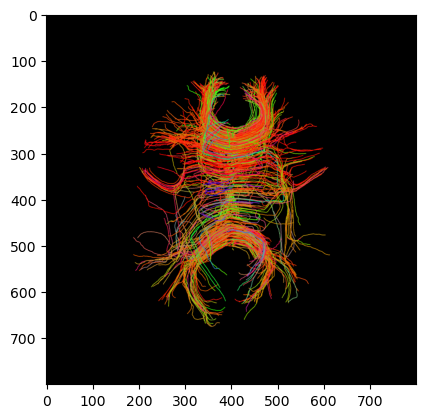

In [19]:
img = plt.imread("tractogram_probabilistic_dg_pmf_2.png")
plt.imshow(img)

In [20]:
# Interactive
window.show(scene)

In [21]:
sft.to_vox()

In [23]:
candidate_sl = sft.streamlines

In [26]:
from os.path import join as pjoin

import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import AxesGrid
import numpy as np

# We'll need to know where the corpus callosum is from these variables:
from dipy.core.gradients import gradient_table
import dipy.core.optimize as opt
from dipy.data import fetch_stanford_tracks, get_fnames
from dipy.io.gradients import read_bvals_bvecs
from dipy.io.image import load_nifti, load_nifti_data
from dipy.io.streamline import load_trk
import dipy.tracking.life as life
from dipy.viz import actor, colormap as cmap, window

hardi_fname, hardi_bval_fname, hardi_bvec_fname = get_fnames(name="stanford_hardi")
label_fname = get_fnames(name="stanford_labels")
t1_fname = get_fnames(name="stanford_t1")

data, affine, hardi_img = load_nifti(hardi_fname, return_img=True)
labels = load_nifti_data(label_fname)
t1_data = load_nifti_data(t1_fname)
bvals, bvecs = read_bvals_bvecs(hardi_bval_fname, hardi_bvec_fname)
gtab = gradient_table(bvals, bvecs=bvecs)

cc_slice = labels == 2

  0%|          | 0/71 [00:00<?, ? MB/s]

In [27]:
# Enables/disables interactive visualization
interactive = False

candidate_streamlines_actor = actor.streamtube(
    candidate_sl, colors=cmap.line_colors(candidate_sl)
)
cc_ROI_actor = actor.contour_from_roi(cc_slice, color=(1.0, 1.0, 0.0), opacity=0.5)

vol_actor = actor.slicer(t1_data)

vol_actor.display(x=40)
vol_actor2 = vol_actor.copy()
vol_actor2.display(z=35)

# Add display objects to canvas
scene = window.Scene()
scene.add(candidate_streamlines_actor)
scene.add(cc_ROI_actor)
scene.add(vol_actor)
scene.add(vol_actor2)
window.record(scene=scene, n_frames=1, out_path="life_candidates.png", size=(800, 800))


In [28]:
window.show(scene)

In [30]:
fiber_model = life.FiberModel(gtab)
inv_affine = np.linalg.inv(hardi_img.affine)

fiber_fit = fiber_model.fit(data, candidate_sl, affine=np.eye(4))

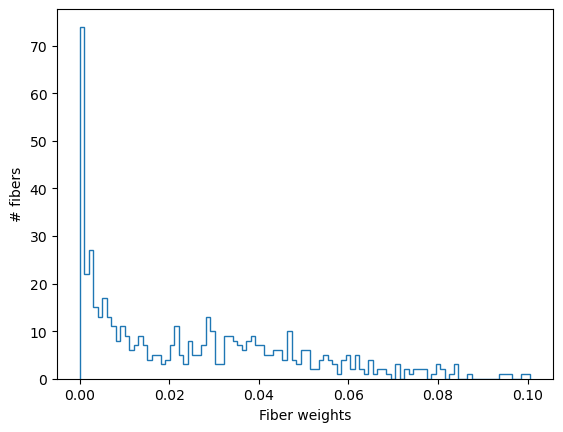

In [31]:
fig, ax = plt.subplots(1)
ax.hist(fiber_fit.beta, bins=100, histtype="step")
ax.set_xlabel("Fiber weights")
ax.set_ylabel("# fibers")
fig.savefig("beta_histogram.png")

In [32]:
optimized_sl = [np.vstack(candidate_sl)[np.where(fiber_fit.beta > 0)[0]]]
scene = window.Scene()
scene.add(actor.streamtube(optimized_sl, colors=cmap.line_colors(optimized_sl)))
scene.add(cc_ROI_actor)
scene.add(vol_actor)
window.record(scene=scene, n_frames=1, out_path="life_optimized.png", size=(800, 800))


In [33]:
window.show(scene)

In [35]:
model_predict = fiber_fit.predict()
model_error = model_predict - fiber_fit.data
model_rmse = np.sqrt(np.mean(model_error[:, 10:] ** 2, -1))

In [36]:
beta_baseline = np.zeros(fiber_fit.beta.shape[0])
pred_weighted = np.reshape(
    opt.spdot(fiber_fit.life_matrix, beta_baseline),
    (fiber_fit.vox_coords.shape[0], np.sum(~gtab.b0s_mask)),
)
mean_pred = np.empty((fiber_fit.vox_coords.shape[0], gtab.bvals.shape[0]))
S0 = fiber_fit.b0_signal

In [37]:
mean_pred[..., gtab.b0s_mask] = S0[:, None]
mean_pred[..., ~gtab.b0s_mask] = (pred_weighted + fiber_fit.mean_signal[:, None]) * S0[
    :, None
]
mean_error = mean_pred - fiber_fit.data
mean_rmse = np.sqrt(np.mean(mean_error**2, -1))

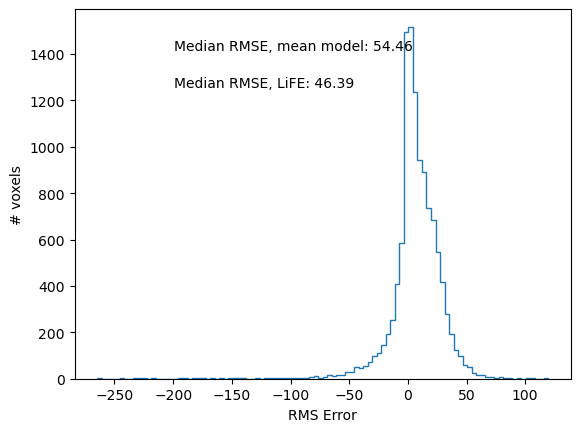

In [38]:
fig, ax = plt.subplots(1)
ax.hist(mean_rmse - model_rmse, bins=100, histtype="step")
ax.text(
    0.2,
    0.9,
    f"Median RMSE, mean model: {np.median(mean_rmse):.2f}",
    horizontalalignment="left",
    verticalalignment="center",
    transform=ax.transAxes,
)
ax.text(
    0.2,
    0.8,
    f"Median RMSE, LiFE: {np.median(model_rmse):.2f}",
    horizontalalignment="left",
    verticalalignment="center",
    transform=ax.transAxes,
)
ax.set_xlabel("RMS Error")
ax.set_ylabel("# voxels")
fig.savefig("error_histograms.png")

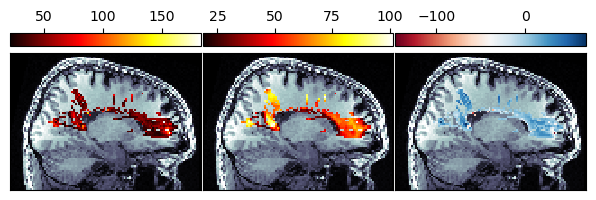

In [39]:
vol_model = np.ones(data.shape[:3]) * np.nan
vol_model[
    fiber_fit.vox_coords[:, 0], fiber_fit.vox_coords[:, 1], fiber_fit.vox_coords[:, 2]
] = model_rmse
vol_mean = np.ones(data.shape[:3]) * np.nan
vol_mean[
    fiber_fit.vox_coords[:, 0], fiber_fit.vox_coords[:, 1], fiber_fit.vox_coords[:, 2]
] = mean_rmse
vol_improve = np.ones(data.shape[:3]) * np.nan
vol_improve[
    fiber_fit.vox_coords[:, 0], fiber_fit.vox_coords[:, 1], fiber_fit.vox_coords[:, 2]
] = mean_rmse - model_rmse
sl_idx = 49
fig = plt.figure()
fig.subplots_adjust(left=0.05, right=0.95)
ax = AxesGrid(
    fig,
    111,
    nrows_ncols=(1, 3),
    label_mode="1",
    share_all=True,
    cbar_location="top",
    cbar_mode="each",
    cbar_size="10%",
    cbar_pad="5%",
)
ax[0].matshow(np.rot90(t1_data[sl_idx, :, :]), cmap=matplotlib.cm.bone)
im = ax[0].matshow(np.rot90(vol_model[sl_idx, :, :]), cmap=matplotlib.cm.hot)
ax.cbar_axes[0].colorbar(im)
ax[1].matshow(np.rot90(t1_data[sl_idx, :, :]), cmap=matplotlib.cm.bone)
im = ax[1].matshow(np.rot90(vol_mean[sl_idx, :, :]), cmap=matplotlib.cm.hot)
ax.cbar_axes[1].colorbar(im)
ax[2].matshow(np.rot90(t1_data[sl_idx, :, :]), cmap=matplotlib.cm.bone)
im = ax[2].matshow(np.rot90(vol_improve[sl_idx, :, :]), cmap=matplotlib.cm.RdBu)
ax.cbar_axes[2].colorbar(im)
for lax in ax:
    lax.set_xticks([])
    lax.set_yticks([])
fig.savefig("spatial_errors.png")